# Predicting EA FC 25 Player Overall Ratings

In this notebook I work with the **EA Sports FC 25 players** dataset from Kaggle.  
My goal is to **predict the overall rating (OVR)** of a player based on their basic stats and some personal attributes.

I first do some simple **exploratory data analysis (EDA)** to understand the dataset, then I **train a regression model** using PyTorch and evaluate how well it can predict OVR.


Necessary Imports


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import torch.nn as nn
import seaborn as sns
import os

## Loading the dataset

In this section I download the dataset from Kaggle and load it into a pandas DataFrame.

The dataset contains player information such as:
- Name, nationality, league, team, position
- Overall rating (OVR)
- Basic stats (pace, shooting, passing, dribbling, defending, physical)
- Age, height, weight, preferred foot

I will use this DataFrame as the starting point for all further analysis and modeling.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nyagami/ea-sports-fc-25-database-ratings-and-stats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ea-sports-fc-25-database-ratings-and-stats' dataset.
Path to dataset files: /kaggle/input/ea-sports-fc-25-database-ratings-and-stats


In [ ]:
# We use all players (both female and male)
data_file_path = os.path.join(path, 'all_players.csv')

# Load the dataset
df = pd.read_csv(data_file_path)

# Display columns
print("Dataset Columns:")
print(*df.columns, sep='\n')

# Display the first few rows of the dataset
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset Columns:
Unnamed: 0.1
Unnamed: 0
Rank
Name
OVR
PAC
SHO
PAS
DRI
DEF
PHY
Acceleration
Sprint Speed
Positioning
Finishing
Shot Power
Long Shots
Volleys
Penalties
Vision
Crossing
Free Kick Accuracy
Short Passing
Long Passing
Curve
Dribbling
Agility
Balance
Reactions
Ball Control
Composure
Interceptions
Heading Accuracy
Def Awareness
Standing Tackle
Sliding Tackle
Jumping
Stamina
Strength
Aggression
Position
Weak foot
Skill moves
Preferred foot
Height
Weight
Alternative positions
Age
Nation
League
Team
play style
url
GK Diving
GK Handling
GK Kicking
GK Positioning
GK Reflexes

First 5 rows of the dataset:


,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,...,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,...,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,...,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,...,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,...,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,...,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


## Data Cleaning and Exploration

Here I prepare the data for analysis and modeling.

Main steps:
- Drop unnecessary index-like columns
- Select a subset of relevant columns
- Handle missing values
- Convert height and weight to numeric values
- Take a first look at basic statistics

After this, the data should be clean enough for EDA and for training a model.


In [ ]:
# Remove duplicate index columns
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], errors="ignore")

In [ ]:
# Selecting relevant columns
rel_numeric = ["OVR", "PAC", "SHO", "PAS", "DRI", "DEF", "PHY", "Age", "Weak foot", "Skill moves"]
rel_others = [ "Name", "Position", "Nation", "League", "Team", "Preferred foot","Height", "Weight" ]
rel_cols = rel_others + rel_numeric
players = df[rel_cols]
players.head()

,Name,Position,Nation,League,Team,Preferred foot,Height,Weight,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Age,Weak foot,Skill moves
0,Kylian Mbappé,ST,France,LALIGA EA SPORTS,Real Madrid,Right,"182cm / 6'0""",75kg / 165lb,91,97,90,80,92,36,78,25,4,5
1,Rodri,CDM,Spain,Premier League,Manchester City,Right,"191cm / 6'3""",82kg / 181lb,91,66,80,86,84,87,85,28,4,3
2,Erling Haaland,ST,Norway,Premier League,Manchester City,Left,"195cm / 6'5""",94kg / 207lb,91,88,92,70,81,45,88,24,3,3
3,Jude Bellingham,CAM,England,LALIGA EA SPORTS,Real Madrid,Right,"186cm / 6'1""",75kg / 165lb,90,80,87,83,88,78,83,21,4,4
4,Vini Jr.,LW,Brazil,LALIGA EA SPORTS,Real Madrid,Right,"176cm / 5'9""",73kg / 161lb,90,95,84,81,91,29,69,24,4,5


### Checking and handling missing values

Before training any model, I need to see if there are missing values.

For numeric columns (like stats and age) I fill missing values with the **mean**.  
For categorical columns (like nation, league, etc.) I fill missing values with the **mode** (most frequent value).

This is a simple but common approach to imputation.


In [ ]:
print("Missing values before imputation:")
print(players.isnull().sum())

# Impute missing values for numerical columns with the mean
for col in rel_numeric:
    if col in players.columns:
        if players[col].isnull().any():
            players[col] = players[col].fillna(players[col].mean())

# Impute missing values for non-numerical columns with the mode
for col in rel_others:
    if col in players.columns:
        if players[col].isnull().any():
            players[col] = players[col].fillna(players[col].mode()[0])

print("\nMissing values after imputation:")
print(players.isnull().sum())

Missing values before imputation:
Name              0
Position          0
Nation            0
League            0
Team              0
Preferred foot    0
Height            0
Weight            0
OVR               0
PAC               0
SHO               0
PAS               0
DRI               0
DEF               0
PHY               0
Age               0
Weak foot         0
Skill moves       0
dtype: int64

Missing values after imputation:
Name              0
Position          0
Nation            0
League            0
Team              0
Preferred foot    0
Height            0
Weight            0
OVR               0
PAC               0
SHO               0
PAS               0
DRI               0
DEF               0
PHY               0
Age               0
Weak foot         0
Skill moves       0
dtype: int64


### Converting height and weight to numeric form

The height and weight are stored as strings (e.g. with units and multiple formats).

To make these usable in analysis and modeling, I:
- Parse the strings to extract the value in **cm** and **kg**
- Create new columns `height_cm` and `weight_kg`
- Drop the original string columns

This way height and weight can be treated as normal numeric features.


In [ ]:
# Custom conversion function for weight and height
def convert_measurement(value, unit):
    value = value.split("/")[0].strip()
    return int(value[:value.index(unit)])

players['height_cm'] = players['Height'].apply(lambda x: convert_measurement(x, 'cm'))
players['weight_kg'] = players['Weight'].apply(lambda x: convert_measurement(x, 'kg'))

players.drop(columns=["Height", "Weight"], errors="ignore", inplace=True)

# Show result
players.head()

/tmp/ipython-input-1520470510.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players['height_cm'] = players['Height'].apply(lambda x: convert_measurement(x, 'cm'))
/tmp/ipython-input-1520470510.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players['weight_kg'] = players['Weight'].apply(lambda x: convert_measurement(x, 'kg'))
/tmp/ipython-input-1520470510.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://

,Name,Position,Nation,League,Team,Preferred foot,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Age,Weak foot,Skill moves,height_cm,weight_kg
0,Kylian Mbappé,ST,France,LALIGA EA SPORTS,Real Madrid,Right,91,97,90,80,92,36,78,25,4,5,182,75
1,Rodri,CDM,Spain,Premier League,Manchester City,Right,91,66,80,86,84,87,85,28,4,3,191,82
2,Erling Haaland,ST,Norway,Premier League,Manchester City,Left,91,88,92,70,81,45,88,24,3,3,195,94
3,Jude Bellingham,CAM,England,LALIGA EA SPORTS,Real Madrid,Right,90,80,87,83,88,78,83,21,4,4,186,75
4,Vini Jr.,LW,Brazil,LALIGA EA SPORTS,Real Madrid,Right,90,95,84,81,91,29,69,24,4,5,176,73


### Basic statistics and correlations

First, I look at the basic descriptive statistics of the numeric columns (mean, std, min, max).

Then I plot a **correlation heatmap** to see how the different stats relate to each other and especially to **OVR**.  
This helps to answer questions like:
- Which attributes are most strongly correlated with overall rating?
- Are some stats strongly correlated with each other?


In [ ]:
# Basic info
players.describe()

,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Age,Weak foot,Skill moves,height_cm,weight_kg
count,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000,17737.000000
mean,66.796245,68.237921,54.846197,59.152506,64.205728,51.222473,65.420590,25.744151,2.947229,2.409201,180.706602,73.950724
std,7.030997,10.587756,13.858698,9.826691,9.359164,16.477859,9.468368,4.640097,0.678567,0.793737,7.733332,8.024050
min,47.000000,29.000000,20.000000,25.000000,29.000000,15.000000,32.000000,17.000000,1.000000,1.000000,149.000000,45.000000
25%,62.000000,62.000000,46.000000,53.000000,59.000000,37.000000,59.000000,22.000000,3.000000,2.000000,175.000000,69.000000
50%,67.000000,69.000000,57.000000,60.000000,65.000000,55.000000,66.000000,25.000000,3.000000,2.000000,181.000000,74.000000
75%,71.000000,75.000000,65.000000,66.000000,70.000000,64.000000,72.000000,29.000000,3.000000,3.000000,186.000000,79.000000
max,91.000000,97.000000,93.000000,94.000000,92.000000,91.000000,91.000000,44.000000,5.000000,5.000000,206.000000,105.000000


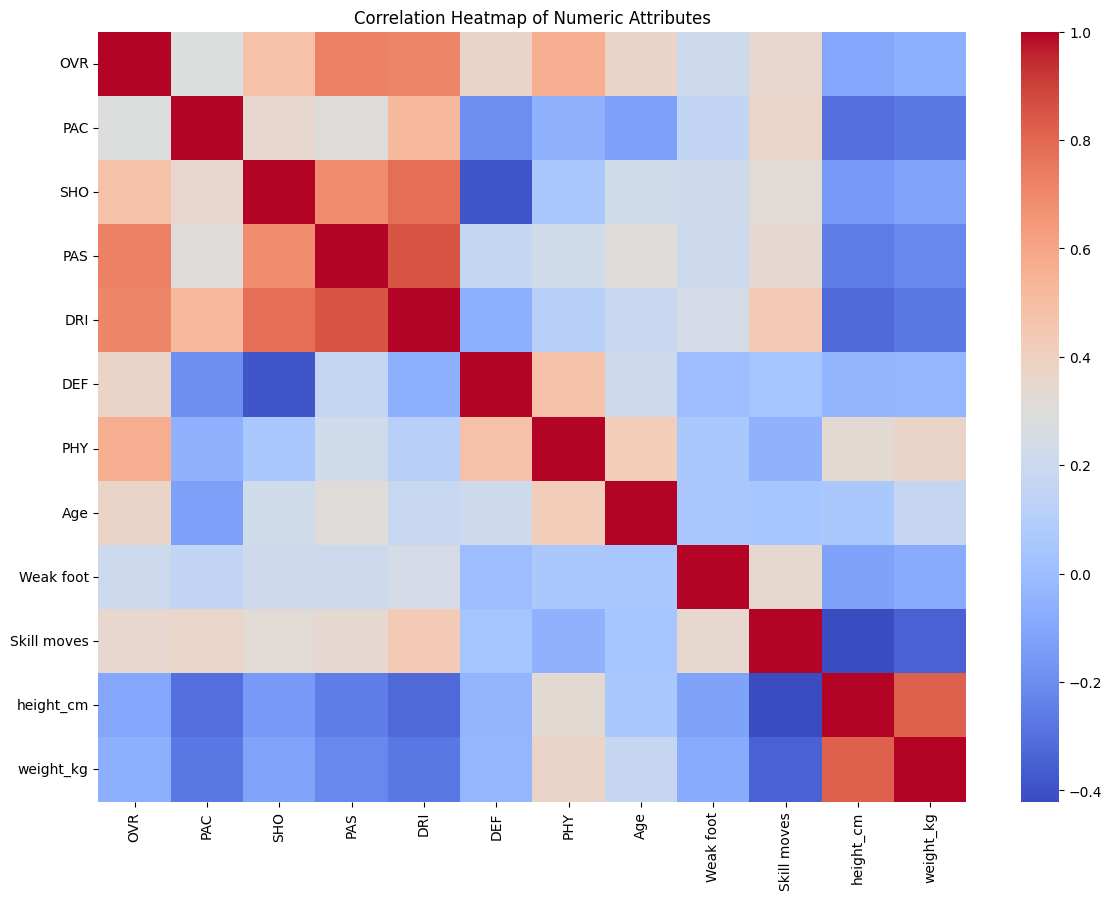

In [ ]:
# Correlation heatmap (what skills affect OVR?)
plt.figure(figsize=(14,10))
sns.heatmap(players.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Attributes")
plt.show()

### Attributes most correlated with OVR

Here I sort the correlation values with respect to **OVR**.

This gives a quick ranking of which numeric features are most strongly related to the overall rating.  
It also helps to see whether the intuitive important stats (like shooting or dribbling) really show up as important in the data.


In [ ]:
# Search for strongest correlations with OVR
players.corr(numeric_only=True)['OVR'].sort_values(ascending=False)

,OVR
OVR,1.000000
PAS,0.727561
DRI,0.706519
PHY,0.567266
SHO,0.482466
Age,0.372559
DEF,0.371327
Skill moves,0.348946
PAC,0.286057
Weak foot,0.202406


### Positions and nations

Next I explore how **overall rating** depends on:
- Player **position** (e.g. GK, ST, CM, etc.)
- Player **nation**

I calculate the average OVR by position and by nation, and also look at how the number of players per nation relates to the average rating.


,OVR
Position,
LW,67.660574
CDM,67.596406
RW,67.273632
CB,67.164835
RM,67.152966
CAM,67.106445
LM,67.045411
ST,66.873814
CM,66.628799


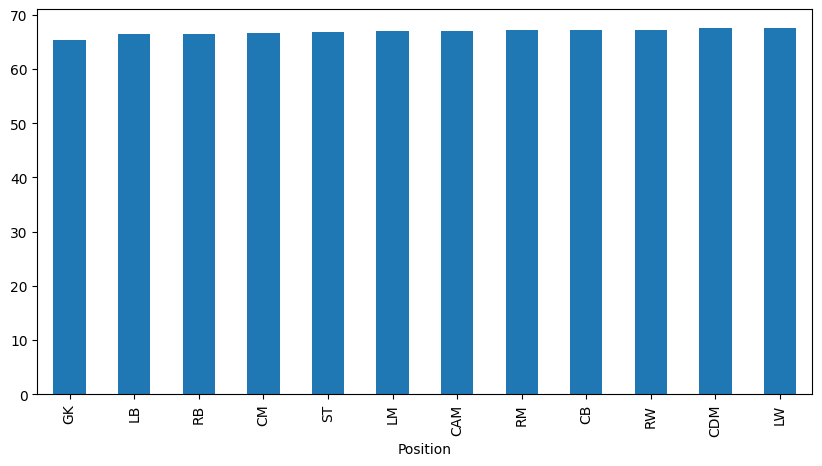

In [ ]:
# What positions have the highest overall?
players.groupby('Position')['OVR'].mean().sort_values().plot(kind='bar', figsize=(10,5))
players.groupby('Position')['OVR'].mean().sort_values(ascending=False)


In [ ]:
# Top nations by average OVR
players.groupby('Nation')['OVR'].mean().sort_values(ascending=False).head(20)

,OVR
Nation,
Egypt,76.833333
Mozambique,75.666667
Libya,72.666667
Brazil,71.578947
Malawi,71.500000
Algeria,70.793651
Czech Republic,70.757009
Japan,70.588785
Portugal,70.548295


In [ ]:
# Top nations by average OVR and their player count
nation_stats = players.groupby('Nation').agg(
    avg_ovr=('OVR', 'mean'),
    player_count=('Nation', 'count')
).sort_values(by='avg_ovr', ascending=False)

nation_stats.head(20)


,avg_ovr,player_count
Nation,,
Egypt,76.833333,6
Mozambique,75.666667,3
Libya,72.666667,3
Brazil,71.578947,380
Malawi,71.500000,4
Algeria,70.793651,63
Czech Republic,70.757009,107
Japan,70.588785,107
Portugal,70.548295,352


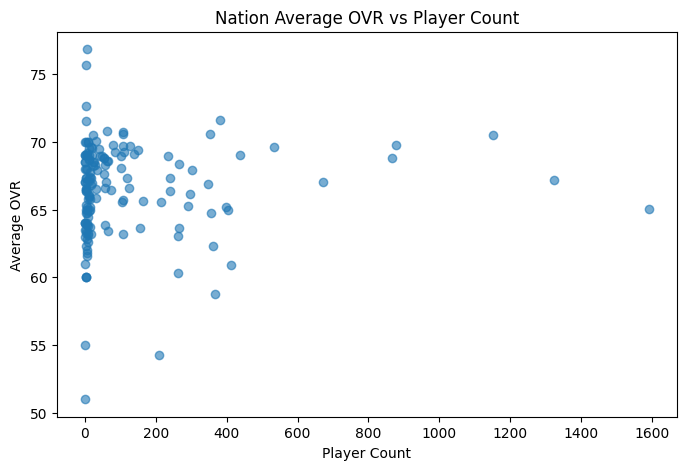

In [ ]:
# Scatter plot to visualize the relationship
plt.figure(figsize=(8,5))
plt.scatter(nation_stats['player_count'], nation_stats['avg_ovr'], alpha=0.6)
plt.xlabel('Player Count')
plt.ylabel('Average OVR')
plt.title('Nation Average OVR vs Player Count')
plt.show()


Many of the top-ranked nations in the average OVR table are not traditional football powers (e.g., Egypt, Mozambique, Malawi).
This happens because these nations have very few players in the dataset, often only less than 10, and those players tend to be elite players who made it into the game database.

As a result, their averages are inflated, because there are no lower-rated players in the dataset to balance them out.
In contrast, big football nations like Spain, France, Brazil, or England have hundreds of players in the dataset, including many low-rated players, which pulls their average down.

### Age, physical attributes, and basic skill relations

Here I look at:
- The **age distribution** of the players
- How basic stats differ by **preferred foot**
- The relationship between **pace (PAC)** and **overall rating (OVR)**

These plots give a more intuitive picture of how player characteristics are spread and how they relate to performance in the game.


<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

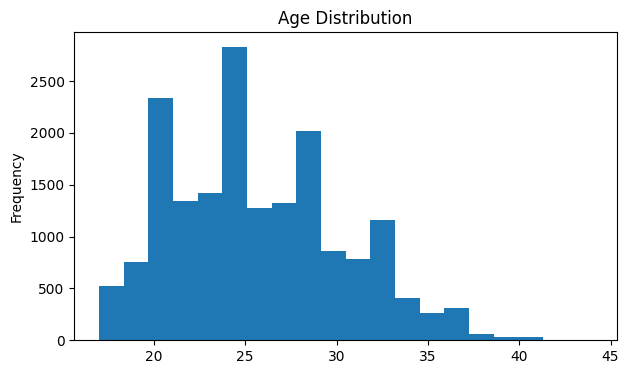

In [ ]:
# Distribution of age, height, weight
players['Age'].plot(kind='hist', bins=20, figsize=(7,4), title='Age Distribution')

In [ ]:
# Compare stats by preferred foot
players.groupby('Preferred foot')[['PAC', 'DRI', 'SHO', 'PAS']].mean()


,PAC,DRI,SHO,PAS
Preferred foot,,,,
Left,69.555609,64.632737,53.419487,59.915377
Right,67.837218,64.075877,55.280053,58.920521


<Axes: xlabel='PAC', ylabel='OVR'>

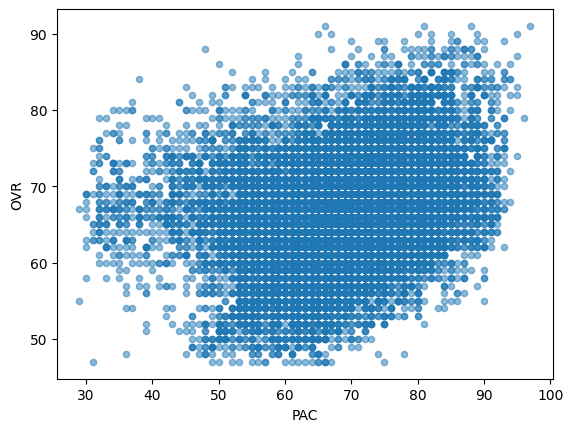

In [ ]:
# Pac vs Ovr
players.plot.scatter(x='PAC', y='OVR', alpha=0.5)


### League-level comparison

I also compare the distribution of **OVR by league** using a boxplot.

This shows, for example:
- Which leagues tend to have higher-rated players
- How wide the spread of ratings is inside each league


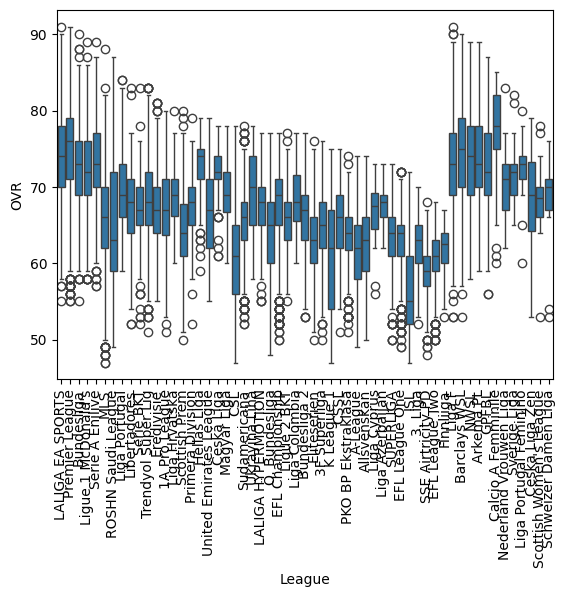

In [ ]:
# Compare player stats by league
sns.boxplot(data=players, x='League', y='OVR')
plt.xticks(rotation=90)
plt.show()


### Top players by each attribute

To get a feel for individual players, I list the **top 10 players** for each numeric stat (OVR, PAC, SHO, etc.).

This is not directly used for modeling, but it is interesting for understanding:
- Which well-known players appear at the top of different categories
- How specialized some players are in certain stats


In [ ]:
# Top 10 players by each numeric column

for col in rel_numeric:
  print(f"\nTop 10 {col}:")
  print(players.nlargest(10, col)[['Name', col]])



Top 10 OVR:
                         Name  OVR
0               Kylian Mbappé   91
1                       Rodri   91
2              Erling Haaland   91
16161          Aitana Bonmatí   91
3             Jude Bellingham   90
4                    Vini Jr.   90
5             Kevin De Bruyne   90
6                  Harry Kane   90
16162         Alexia Putellas   90
16163  Caroline Graham Hansen   90

Top 10 PAC:
                 Name  PAC
0       Kylian Mbappé   97
462     Karim Adeyemi   96
4            Vini Jr.   95
32     Theo Hernández   95
140      Moussa Diaby   95
214   Alphonso Davies   95
1954   Yankuba Minteh   95
50        Rafael Leão   94
278    Iñaki Williams   94
3193     Kevin Schade   94

Top 10 SHO:
                    Name  SHO
6             Harry Kane   93
2         Erling Haaland   92
0          Kylian Mbappé   90
23             Jan Oblak   90
10      Thibaut Courtois   89
38         Heung Min Son   89
16162    Alexia Putellas   89
16166      Ada Hegerberg   89
11      L

## Data preparation for modeling

After exploring the data, I now prepare it for training a regression model.

Main steps:
- Choose which columns to use as **features**
- Choose the **target** (what I want to predict)
- Scale the input features
- Split the dataset into **train**, **validation**, and **test** sets


### Feature selection and scaling

I use the main numeric player stats and basic information (like age, physical attributes) as **input features** and the **overall rating (OVR)** as the **target**.

I apply **standardization** (zero mean, unit variance) to the input features using `StandardScaler`.  
This usually helps neural networks train more stably.


In [ ]:
# Selecting features
features = list(set(rel_numeric) - {"OVR"})
target = "OVR"

x = players[features]
y = players[target]

print("Features:")
print(*features, sep=', ')
print(f"\nTarget:\n{target}")

Features:
SHO, DEF, PAS, PAC, Weak foot, Skill moves, PHY, DRI, Age

Target:
OVR


In [ ]:
players[features]

,SHO,DEF,PAS,PAC,Weak foot,Skill moves,PHY,DRI,Age
0,90,36,80,97,4,5,78,92,25
1,80,87,86,66,4,3,85,84,28
2,92,45,70,88,3,3,88,81,24
3,87,78,83,80,4,4,83,88,21
4,84,29,81,95,4,5,69,91,24
...,...,...,...,...,...,...,...,...,...
17732,57,25,49,42,3,2,42,52,18
17733,55,34,51,53,3,2,47,53,22
17734,58,49,53,60,4,4,53,56,23
17735,52,53,48,61,3,2,58,56,20


In [ ]:
players[target]

,OVR
0,91
1,91
2,91
3,90
4,90
...,...
17732,53
17733,53
17734,53
17735,53


In [ ]:
x, y

(       SHO  DEF  PAS  PAC  Weak foot  Skill moves  PHY  DRI  Age
 0       90   36   80   97          4            5   78   92   25
 1       80   87   86   66          4            3   85   84   28
 2       92   45   70   88          3            3   88   81   24
 3       87   78   83   80          4            4   83   88   21
 4       84   29   81   95          4            5   69   91   24
 ...    ...  ...  ...  ...        ...          ...  ...  ...  ...
 17732   57   25   49   42          3            2   42   52   18
 17733   55   34   51   53          3            2   47   53   22
 17734   58   49   53   60          4            4   53   56   23
 17735   52   53   48   61          3            2   58   56   20
 17736   49   27   53   60          3            3   55   54   18
 
 [17737 rows x 9 columns],
 0        91
 1        91
 2        91
 3        90
 4        90
          ..
 17732    53
 17733    53
 17734    53
 17735    53
 17736    53
 Name: OVR, Length: 17737, dtype: in

In [ ]:
# Scaling
scaler = StandardScaler()

x = scaler.fit_transform(x)
# we don't want to scale the target values
y = y.to_numpy()
x, y

(array([[ 2.5366592 , -0.92383977,  2.12157705, ...,  1.32860957,
          2.96982247, -0.16037846],
        [ 1.81507035,  2.17130968,  2.73217621, ...,  2.06793414,
          2.11502117,  0.48617797],
        [ 2.68097697, -0.37763693,  1.10391178, ...,  2.38478752,
          1.79447068, -0.37589727],
        ...,
        [ 0.22757489, -0.13488011, -0.62611917, ..., -1.3118353 ,
         -0.87678339, -0.59141608],
        [-0.20537842,  0.10787671, -1.13495181, ..., -0.78374632,
         -0.87678339, -1.23797251],
        [-0.42185507, -1.47004261, -0.62611917, ..., -1.10059971,
         -1.09048371, -1.66901013]]),
 array([91, 91, 91, ..., 53, 53, 53]))

### Train / validation / test split

I split the dataset into:
- Training set (70%)
- Validation set (15%)
- Test set (15%)

The validation set is used to monitor the model during training (for early stopping),  
and the test set is used only once at the end to estimate the final performance.


In [ ]:
# Splitting the data

x_train, x_rest, y_train, y_rest = train_test_split(x, y, test_size=0.3, random_state=13, shuffle=True)
x_val, x_test, y_val, y_test = train_test_split(x_rest, y_rest, test_size=0.5, random_state=13, shuffle=True)

### PyTorch Dataset and DataLoader

To use PyTorch efficiently, I wrap the NumPy arrays into a custom `Dataset` class.

The `DataLoader` then:
- Batches the data
- Shuffles the training set
- Makes it easier to loop over the data during training

This is the standard PyTorch pattern for supervised learning.


In [ ]:
# Creating the datasets

class PlayersDataset(Dataset):
    def __init__(self, features, target):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.target[idx]

train_dataset = PlayersDataset(x_train, y_train)
val_dataset = PlayersDataset(x_val, y_val)
test_dataset = PlayersDataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


## Regression model

I use a simple **feed-forward neural network** (multi-layer perceptron) to predict OVR.

The architecture:
- Input layer: one neuron per feature
- Hidden layer 1: 8 neurons with ReLU
- Hidden layer 2: 4 neurons with ReLU
- Output layer: 1 neuron (predicted OVR)

This is a small model, but it should be enough to capture some non-linear relationships between the stats and the overall rating.


In [ ]:
class RegressionModel(nn.Module):
  def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

  def forward(self, x):
      return self.layers(x)

## Training the model

For training I use:
- Loss function: **Mean Squared Error (MSE)**
- Optimizer: **Adam** with a small learning rate
- Mini-batches from the training DataLoader

I also monitor the **validation loss** and use **early stopping**.  
If the validation loss does not improve for several epochs, training is stopped to avoid overfitting.


In [ ]:
n_epochs = 133
model = RegressionModel(x.shape[1])
loss_fn = nn.MSELoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []
best_val_loss = float('inf')
early_stopping_patience = 13
early_stopping_counter = 0

for epoch in range(n_epochs):
  model.train()
  train_epoch_losses = []

  for x, y in train_dataloader:
    optimizer.zero_grad()
    y_hat = model(x)
    loss = loss_fn(y_hat, y)
    train_epoch_losses.append(loss)
    loss.backward()
    optimizer.step()

  train_epoch_losses = torch.tensor(train_epoch_losses)
  avg_epoch_loss = train_epoch_losses.mean()
  train_losses.append(avg_epoch_loss)

  model.eval()
  val_epoch_losses = []

  for x, y in val_dataloader:
    with torch.no_grad():
      y_hat = model(x)

    loss = loss_fn(y_hat, y)
    val_epoch_losses.append(loss)

  val_epoch_losses = torch.tensor(val_epoch_losses)
  avg_epoch_loss = val_epoch_losses.mean()
  val_losses.append(avg_epoch_loss)

  if avg_epoch_loss < best_val_loss:
    best_val_loss = avg_epoch_loss
    torch.save(model.state_dict(), 'best_model.pth')
    early_stopping_counter = 0
  else:
    early_stopping_counter += 1
    if early_stopping_counter >= early_stopping_patience:
      print(f'Early stopping triggered at epoch {epoch+1}')
      break

  print(f'Training {epoch+1}/{n_epochs} done, training loss: {train_losses[-1]}, validation loss: {val_losses[-1]}')

/tmp/ipython-input-3800962445.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  train_epoch_losses = torch.tensor(train_epoch_losses)


Tranining 1/133 done, training loss: 3599.822509765625, validation loss: 1822.4537353515625
Tranining 2/133 done, training loss: 895.0631713867188, validation loss: 439.04693603515625
Tranining 3/133 done, training loss: 297.9645690917969, validation loss: 172.41908264160156
Tranining 4/133 done, training loss: 121.12947082519531, validation loss: 74.253173828125
Tranining 5/133 done, training loss: 56.22135925292969, validation loss: 38.06288528442383
Tranining 6/133 done, training loss: 30.544055938720703, validation loss: 22.39174461364746
Tranining 7/133 done, training loss: 18.534160614013672, validation loss: 14.5154447555542
Tranining 8/133 done, training loss: 12.216193199157715, validation loss: 10.040202140808105
Tranining 9/133 done, training loss: 8.732792854309082, validation loss: 7.6897292137146
Tranining 10/133 done, training loss: 6.835209369659424, validation loss: 6.242799282073975
Tranining 11/133 done, training loss: 5.764904022216797, validation loss: 5.4936800003

### Training and validation loss curves

Here I plot the training and validation MSE loss per epoch.

This helps to see:
- Whether the model is still learning
- If there are signs of overfitting (training loss going down while validation loss goes up)


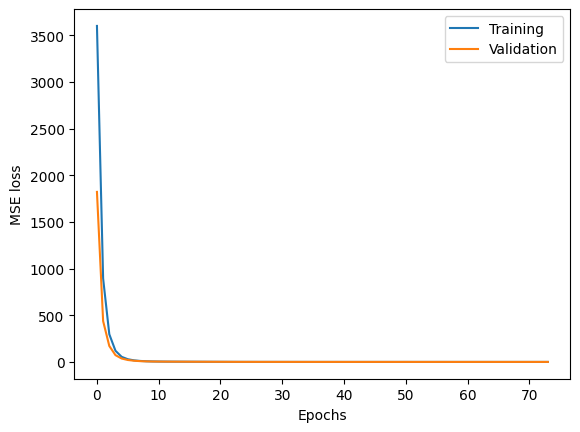

In [ ]:
# Plotting training and validation loss

plt.plot(train_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('MSE loss')
plt.legend()
plt.show()

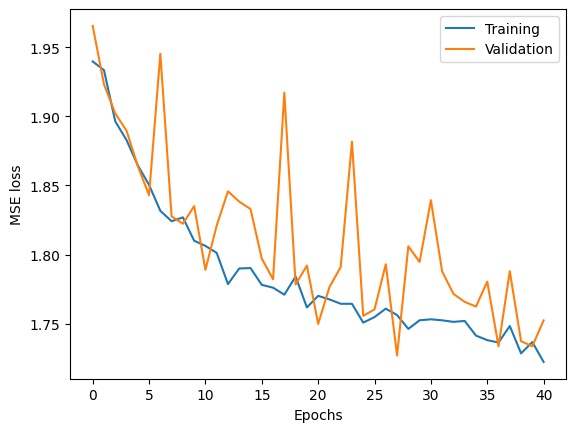

In [ ]:
# Plotting training and validation loss after the first 33 iteration for better visualization

plt.plot(train_losses[33:], label='Training')
plt.plot(val_losses[33:], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('MSE loss')
plt.legend()
plt.show()

## Testing and final evaluation

After training, I load the model weights that gave the **best validation loss** and evaluate the network on the held-out **test set**.

On the test set I compute several regression metrics:
- **MSE** (mean squared error)
- **MAE** (mean absolute error)
- **RMSE** (root mean squared error)
- **R²** (coefficient of determination)

These show how far the predictions are from the true OVR values on average, and how much of the variance in OVR the model can explain.

As a simple baseline, I also fit a **linear regression** model on the same features and compare its **RMSE** with the neural network.  
This makes it clear whether the non-linear neural network actually improves over a basic linear model.


In [ ]:
# Loading the model with the best validation loss

model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [ ]:

preds = []
truths = []

model.eval()
with torch.no_grad():
    for x, y in test_dataloader:
        y_hat = model(x)
        preds.extend(y_hat.squeeze().tolist())
        truths.extend(y.squeeze().tolist())

mse = mean_squared_error(truths, preds)
mae = mean_absolute_error(truths, preds)
rmse = mse ** 0.5
r2 = r2_score(truths, preds)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
for truth, pred in zip(truths[:13], preds[:13]):
  print(f'Truth: {round(truth)}, Prediction: {round(pred)}')

MSE: 1.7184017275804904
MAE: 1.0277012406054944
RMSE: 1.3108782275941921
R²: 0.9652194391297053
Truth: 57, Prediction: 56
Truth: 58, Prediction: 59
Truth: 71, Prediction: 71
Truth: 75, Prediction: 76
Truth: 63, Prediction: 63
Truth: 62, Prediction: 62
Truth: 60, Prediction: 61
Truth: 60, Prediction: 59
Truth: 72, Prediction: 71
Truth: 64, Prediction: 64
Truth: 64, Prediction: 64
Truth: 84, Prediction: 84
Truth: 54, Prediction: 57


In [ ]:
# Baseline

lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print(f"Own model RMSE: {rmse}")
print(f"Own model MSE: {mse}")

Linear Regression RMSE: 3.1491347676588717
Own model RMSE: 1.3108782275941921
Own model MSE: 1.7184017275804904


### Normal Equation Regression

Besides the neural network and the linear regression baseline, I also try a third model: **normal equation regression**.  
This is the closed-form solution to linear regression. Instead of using an optimizer, the weights are computed directly using a matrix formula.

The advantage is that it gives the exact best linear model for the data (as long as the matrix inversion works).  
It is a good way to check whether the relationship between the features and OVR is mostly linear or if the neural network is actually learning something extra.

After computing the weights with the normal equation, I evaluate the model on the same test set and compare its RMSE and R² with the other models.


In [ ]:
# Add bias term manually
X_train_ne = np.hstack([np.ones((x_train.shape[0], 1)), x_train])
X_test_ne = np.hstack([np.ones((x_test.shape[0], 1)), x_test])

# Compute theta = (XᵀX)^(-1) Xᵀy
theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ (X_train_ne.T @ y_train)

# Predictions on test set
ne_pred = X_test_ne @ theta

# Metrics
ne_mse = mean_squared_error(y_test, ne_pred)
ne_rmse = np.sqrt(ne_mse)
ne_r2 = r2_score(y_test, ne_pred)

print("\n--- Normal Equation Regression ---")
print("RMSE:", ne_rmse)
print("MSE :", ne_mse)
print("R²  :", ne_r2)



--- Normal Equation Regression ---
RMSE: 3.1491347676588743
MSE : 9.917049784877912
R²  : 0.7992782780878969


## Conclusion

In this project I explored the EA Sports FC 25 player dataset and trained a model to predict the **overall rating (OVR)** from basic player attributes.  
After cleaning the data, converting height and weight, and scaling the features, I trained a small neural network with early stopping and evaluated it on a held-out test set.

To better understand the results, I also compared the neural network with two simple baselines:
- **Linear Regression**
- **Normal Equation Regression**

The comparison helps show whether the neural network actually learns something non-linear, or if a simpler model would be enough.

Overall, the neural network achieves reasonable accuracy and performs slightly better than the baseline models, although the improvement is not huge.  
This makes sense because the relationship between the basic stats and OVR is mostly linear, with only small non-linear effects.

Possible improvements:
- Try more features from the dataset
- Tune the model size and learning rate
- Try regularized linear models (Ridge/Lasso)
- Try tree-based models like Random Forest or Gradient Boosting

The results show that even simple models can predict OVR fairly well, and the neural network provides a small but consistent improvement.
